# NLP Project - polish songs - prediction of year from lyrics

In [1]:
# !pip install transformers datasets accelerate torch scikit-learn pandas numpy safetensors

In [2]:
import re
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

## CONFIG

In [3]:
MODEL_NAME = "allegro/herbert-base-cased"
# MODEL_NAME = "dkleczek/bert-base-polish-uncased-v1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LEN = 256                 # chunk length
MAX_CHUNKS = 8                 # for hierarchical model
BATCH_SIZE = 8
EPOCHS = 4
LR = 2e-5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## LOAD DATA

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("carlosgdcj/genius-song-lyrics-with-language-information")

# print("Path to dataset files:", path)

In [5]:
# all_data = pd.read_csv(path+"/song_lyrics.csv", nrows=1000000)
# all_data = all_data[all_data["language"] == 'pl']
# all_data = all_data[all_data["tag"] != 'misc']
# for i in range(1,4):
#   data = pd.read_csv(path+"/song_lyrics.csv", nrows=1000000, skiprows=range(1,(i-1)*1000000))
#   data = data[data["language"] == 'pl']
#   data = data[data["tag"] != 'misc']
#   all_data = pd.concat([all_data, data])

# all_data

In [ ]:
# all_data.to_csv("data/piosenki.csv")

In [ ]:
all_data = pd.read_csv("data/piosenki.csv")
df = all_data.dropna(subset=["lyrics", "year"]).copy()
df = df[df["language"] == "pl"].copy()
df["year"] = df["year"].astype(float)

In [8]:
all_data["tag"].value_counts()

tag
rap        47282
pop        11681
rock        3839
rb           199
country       37
Name: count, dtype: int64

In [9]:
all_data[all_data["tag"]=="rock"]

,Unnamed: 0.1,Unnamed: 0,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
261,261,163520,12 Groszy,rock,Kazik,1997,21893,{},"[Hook]\n12 groszy, tylko nie płacz proszę\n12 ...",177101,pl,pl,pl
2305,2307,247642,Rolowanie,rock,Natasza Urbaska,2014,2850,"{""Natasza Urbańska""}",[Verse 1: Natasza] x2\nWielki mi big deal\nAft...,333309,pl,pl,pl
2465,2467,256200,Porozumienie ponad podziałami,rock,Kazik,1995,278,{},[Verse 1]\nTo jest porozumienie ponad podziała...,347525,pl,pl,pl
2466,2468,256201,Oddalenie,rock,Kazik,1995,575,{},[Intro]\n- Jeżeli będę odpowiadał nie na temat...,347529,pl,pl,pl
2469,2471,256241,Zgredzi,rock,Kazik,1995,186,{},"[ZWROTKA 1]\nZgredzi to są starzy, a starzy to...",347669,pl,pl,pl
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62895,62923,990838,Ślad,rock,Deadtedi,2019,10,{},"Ja chciałem ciebie obok, a pozostał ślad\nPo t...",4517300,pl,pl,pl
62941,62969,993067,Wataha,rock,Mskie Granie Orkiestra,2016,761,"{O.S.T.R.,""Dawid Podsiadło"",ØRGANEK,""Męskie Gr...",Upadłem i choć brak mi sił\nPodniosę się i pob...,4521002,pl,pl,pl
62965,62993,994558,Rozbiłaś mi serce,rock,Deadtedi,2019,28,{},Nie chciałem za wiele\nRozbiłaś mi serce\nNikt...,4523399,pl,pl,pl
62968,62996,995398,Chciałem dla ciebie jak najlepiej ale oni cię ...,rock,Deadtedi,2019,45,{Vorpi},"[maly tedi]\nRozbiłaś mi serce, teraz rozpętaj...",4524739,pl,pl,pl


## PREPROCESSING

In [10]:
l = str(all_data.iloc[4909]["lyrics"])
l

'Surogat ersatz\nEmulgator szczęścia\nKonserwanty uczuć\nPasteryzowany raj\n\nSubstytut serca\nZoperowane piękna\nKolagenowy uśmiech\nAkcyzowany haj\n\nUjędrniana starość, rozpycha się nabzdyczona\nSflaczałe atrybuty utopiła w botoxie\nŻywność modyfikuje się sama, bez opamiętania\nMałość skalpelem tnie kompleksy bezlitośnie\n\n(Ref.)\n\nKastrowanie singlem, jinglem, sloganem, banałem\nUczysz się na pamięć haseł podanych w reklamie\nZnieczulenie umysłowe usuwa zmarszczki przy oczach\nKorekcja myślenia, plastyka pochwy i krocza\n(na pokaz!)\nErzatz jesz\nBierz ersatz, bierz\nEmulgato - konserwante\nEmulgato - surogato\n\nZakamuflowany przekaz podprogowy chłam\nWydrukowane tony papierowych kłamstw\nKody kreskowe na przemyśleniach do wykupienia\nAborcja wątpliwości, bez znieczulenia\n\nJednowymiarowy blichtr, tranzyt potrzeb\nKorekcyjna gimnastyka oportunistycznych zwiotczeń\nAbsorpcja przez afirmację, bez odrzutów\nLukrowany raj transmitowany przez bluetooth'

In [11]:
#remove brackets
l=re.sub(r"\[.*?\]","",l)
l

'Surogat ersatz\nEmulgator szczęścia\nKonserwanty uczuć\nPasteryzowany raj\n\nSubstytut serca\nZoperowane piękna\nKolagenowy uśmiech\nAkcyzowany haj\n\nUjędrniana starość, rozpycha się nabzdyczona\nSflaczałe atrybuty utopiła w botoxie\nŻywność modyfikuje się sama, bez opamiętania\nMałość skalpelem tnie kompleksy bezlitośnie\n\n(Ref.)\n\nKastrowanie singlem, jinglem, sloganem, banałem\nUczysz się na pamięć haseł podanych w reklamie\nZnieczulenie umysłowe usuwa zmarszczki przy oczach\nKorekcja myślenia, plastyka pochwy i krocza\n(na pokaz!)\nErzatz jesz\nBierz ersatz, bierz\nEmulgato - konserwante\nEmulgato - surogato\n\nZakamuflowany przekaz podprogowy chłam\nWydrukowane tony papierowych kłamstw\nKody kreskowe na przemyśleniach do wykupienia\nAborcja wątpliwości, bez znieczulenia\n\nJednowymiarowy blichtr, tranzyt potrzeb\nKorekcyjna gimnastyka oportunistycznych zwiotczeń\nAbsorpcja przez afirmację, bez odrzutów\nLukrowany raj transmitowany przez bluetooth'

In [12]:
#remove stutter
l = re.sub(r"(([a-z])-)+\1","", l)
l

'Surogat ersatz\nEmulgator szczęścia\nKonserwanty uczuć\nPasteryzowany raj\n\nSubstytut serca\nZoperowane piękna\nKolagenowy uśmiech\nAkcyzowany haj\n\nUjędrniana starość, rozpycha się nabzdyczona\nSflaczałe atrybuty utopiła w botoxie\nŻywność modyfikuje się sama, bez opamiętania\nMałość skalpelem tnie kompleksy bezlitośnie\n\n(Ref.)\n\nKastrowanie singlem, jinglem, sloganem, banałem\nUczysz się na pamięć haseł podanych w reklamie\nZnieczulenie umysłowe usuwa zmarszczki przy oczach\nKorekcja myślenia, plastyka pochwy i krocza\n(na pokaz!)\nErzatz jesz\nBierz ersatz, bierz\nEmulgato - konserwante\nEmulgato - surogato\n\nZakamuflowany przekaz podprogowy chłam\nWydrukowane tony papierowych kłamstw\nKody kreskowe na przemyśleniach do wykupienia\nAborcja wątpliwości, bez znieczulenia\n\nJednowymiarowy blichtr, tranzyt potrzeb\nKorekcyjna gimnastyka oportunistycznych zwiotczeń\nAbsorpcja przez afirmację, bez odrzutów\nLukrowany raj transmitowany przez bluetooth'

In [13]:
l = re.sub(r"['-]","", l)
l

'Surogat ersatz\nEmulgator szczęścia\nKonserwanty uczuć\nPasteryzowany raj\n\nSubstytut serca\nZoperowane piękna\nKolagenowy uśmiech\nAkcyzowany haj\n\nUjędrniana starość, rozpycha się nabzdyczona\nSflaczałe atrybuty utopiła w botoxie\nŻywność modyfikuje się sama, bez opamiętania\nMałość skalpelem tnie kompleksy bezlitośnie\n\n(Ref.)\n\nKastrowanie singlem, jinglem, sloganem, banałem\nUczysz się na pamięć haseł podanych w reklamie\nZnieczulenie umysłowe usuwa zmarszczki przy oczach\nKorekcja myślenia, plastyka pochwy i krocza\n(na pokaz!)\nErzatz jesz\nBierz ersatz, bierz\nEmulgato  konserwante\nEmulgato  surogato\n\nZakamuflowany przekaz podprogowy chłam\nWydrukowane tony papierowych kłamstw\nKody kreskowe na przemyśleniach do wykupienia\nAborcja wątpliwości, bez znieczulenia\n\nJednowymiarowy blichtr, tranzyt potrzeb\nKorekcyjna gimnastyka oportunistycznych zwiotczeń\nAbsorpcja przez afirmację, bez odrzutów\nLukrowany raj transmitowany przez bluetooth'

In [14]:
l = re.sub(r"[^a-zA-ZąćęńśłóżźĄĆĘŃŚŁÓŻŹ ]"," ", l)
l

'Surogat ersatz Emulgator szczęścia Konserwanty uczuć Pasteryzowany raj  Substytut serca Zoperowane piękna Kolagenowy uśmiech Akcyzowany haj  Ujędrniana starość  rozpycha się nabzdyczona Sflaczałe atrybuty utopiła w botoxie Żywność modyfikuje się sama  bez opamiętania Małość skalpelem tnie kompleksy bezlitośnie   Ref    Kastrowanie singlem  jinglem  sloganem  banałem Uczysz się na pamięć haseł podanych w reklamie Znieczulenie umysłowe usuwa zmarszczki przy oczach Korekcja myślenia  plastyka pochwy i krocza  na pokaz   Erzatz jesz Bierz ersatz  bierz Emulgato  konserwante Emulgato  surogato  Zakamuflowany przekaz podprogowy chłam Wydrukowane tony papierowych kłamstw Kody kreskowe na przemyśleniach do wykupienia Aborcja wątpliwości  bez znieczulenia  Jednowymiarowy blichtr  tranzyt potrzeb Korekcyjna gimnastyka oportunistycznych zwiotczeń Absorpcja przez afirmację  bez odrzutów Lukrowany raj transmitowany przez bluetooth'

In [15]:
def preprocess(lyrics):
    lyrics=str(lyrics)
    if "uncased" in MODEL_NAME:
        lyrics = lyrics.lower()
    #remove brackets
    lyrics=re.sub(r"\[.*?\]","",lyrics)
    #remove stutter
    lyrics = re.sub(r"(([a-z])-)+\1","", lyrics)
    #punctuation
    lyrics = re.sub(r"[,-]","", lyrics)
    lyrics = re.sub(r"[^a-zA-ZąćęńśłóżźĄĆĘŃŚŁÓŻŹ ]"," ", lyrics)
    return lyrics.strip()

In [16]:
df["lyrics"] = df["lyrics"].apply(preprocess)

## TARGET NORMALIZATION

In [17]:
def standardize_years(years, mean, std):
    return (np.asarray(years, dtype=np.float32) - mean) / std

def inverse_standardize_years(scaled_years, mean, std):
    return np.asarray(scaled_years, dtype=np.float32) * std + mean

In [18]:
y = np.array([1995.0, 2005.0, 2018.0])
mean = y.mean()
std = y.std()
scaled = standardize_years(y, mean, std)
restored = inverse_standardize_years(scaled, mean, std)
assert np.allclose(y, restored), "Inverse scaling failed"
print("Inverse scaling sanity check passed.")

Inverse scaling sanity check passed.


In [19]:
year_mean = float(df["year"].mean())
year_std = float(df["year"].std())
df["target"] = standardize_years(df["year"], year_mean, year_std)

## TOKENIZER

In [20]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [21]:
text = preprocess(all_data.iloc[4909]["lyrics"])
input_ids = tokenizer(text)['input_ids']
tokens = tokenizer.convert_ids_to_tokens(input_ids)
tokens[:30]

['<s>',
 'S',
 'uro',
 'gat</w>',
 'er',
 'sa',
 'tz</w>',
 'E',
 'mul',
 'g',
 'ator</w>',
 'szczęścia</w>',
 'Kon',
 'ser',
 'wan',
 'ty</w>',
 'uczuć</w>',
 'Pa',
 'stery',
 'zowany</w>',
 'raj</w>',
 'Sub',
 'stytu',
 't</w>',
 'serca</w>',
 'Zo',
 'per',
 'owane</w>',
 'piękna</w>',
 'Kola']

In [22]:
tokenizer.encode(tokens[3])

[0, 34993, 1841, 1888, 1019, 1922, 2]

In [23]:
type(tokenizer)

transformers.models.herbert.tokenization_herbert.HerbertTokenizer

## CHUNKING

In [24]:
def build_chunk_input(chunk_token_ids, tokenizer, max_len):
    """
    chunk_token_ids: list[int] WITHOUT special tokens
    returns input_ids, attention_mask tensors of shape [max_len]
    """
    cls_id = tokenizer.cls_token_id
    sep_id = tokenizer.sep_token_id
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    seq = [cls_id] + chunk_token_ids + [sep_id]
    seq = seq[:max_len]

    attn = [1] * len(seq)
    if len(seq) < max_len:
        pad_n = max_len - len(seq)
        seq = seq + [pad_id] * pad_n
        attn = attn + [0] * pad_n

    return (
        torch.tensor(seq, dtype=torch.long),
        torch.tensor(attn, dtype=torch.long),
    )
    

def split_ids_into_chunks(token_ids, chunk_content_len):
    if len(token_ids) == 0:
        token_ids = [tokenizer.unk_token_id]
    return [token_ids[i:i + chunk_content_len] for i in range(0, len(token_ids), chunk_content_len)]

# def sample_random_chunk(token_ids, chunk_content_len):
#     if len(token_ids) <= chunk_content_len:
#         return token_ids
#     start = random.randint(0, len(token_ids) - chunk_content_len)
#     return token_ids[start:start + chunk_content_len]

# def first_and_last_chunks(token_ids, chunk_content_len):
#     if len(token_ids) <= chunk_content_len:
#         return token_ids, token_ids
#     first = token_ids[:chunk_content_len]
#     last = token_ids[-chunk_content_len:]
#     return first, last

## TRAIN / VAL SPLIT

In [25]:
train_df, val_df = train_test_split(
    df[["lyrics", "year", "target"]],
    test_size=0.1,
    random_state=SEED
)

## DATASET

In [26]:
class LyricsDataset(Dataset):
    def __init__(self, texts, targets):
        # self.texts = list(texts)
        self.targets = list(targets)
        self.token_ids = [
            tokenizer.encode(text, add_special_tokens=False)
            for text in texts
        ]
        self.chunks = [split_ids_into_chunks(ids, MAX_LEN - 2) for ids in self.token_ids]

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            # "text": self.texts[idx],
            "target": float(self.targets[idx]),
            # "token_ids": self.token_ids[idx],
            "chunks": self.chunks[idx],
        }
        
train_ds = LyricsDataset(train_df["lyrics"], train_df["target"])
val_ds = LyricsDataset(val_df["lyrics"], val_df["target"])
small_train_ds = LyricsDataset(train_df["lyrics"][:9000], train_df["target"][:9000])
small_val_ds = LyricsDataset(val_df["lyrics"][:1000], val_df["target"][:1000])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (627 > 512). Running this sequence through the model will result in indexing errors


## POOLING

In [27]:
def mean_pooling(last_hidden_state, attention_mask):
    """
    last_hidden_state: [B, L, H]
    attention_mask: [B, L]
    """
    mask = attention_mask.unsqueeze(-1).float()  # [B, L, 1]
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

## EVALUATION

In [28]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    preds_year = []
    gold_year = []

    for batch in loader:
        target = batch.pop("target").numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        pred_scaled = model(**batch).detach().cpu().numpy()

        pred_year = inverse_standardize_years(pred_scaled, year_mean, year_std)
        true_year = inverse_standardize_years(target, year_mean, year_std)

        preds_year.extend(pred_year.tolist())
        gold_year.extend(true_year.tolist())

    return mean_absolute_error(gold_year, preds_year)


## TRAINING

In [29]:
def train_one_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    loss_fn = nn.HuberLoss()

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * total_steps)),
        num_training_steps=total_steps
    )

    best_mae = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad()

            target = batch.pop("target").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            preds = model(**batch)
            loss = loss_fn(preds, target)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            train_losses.append(loss.item())

        val_mae = evaluate_model(model, val_loader)

        print(f"Epoch {epoch + 1}/{epochs} | train_loss={np.mean(train_losses):.4f} | val_MAE={val_mae:.2f} years")

        if val_mae < best_mae:
            best_mae = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

## CHUNKING CHOICE

### RANDOM

#### COLLATE

In [30]:
def collate_random_chunk(batch, tokenizer, max_len=MAX_LEN):
    """
    Random chunk training:
    every time a sample is seen, one random chunk is chosen.
    """

    input_ids_list, attention_list, targets = [], [], []

    for item in batch:
        chunks = item["chunks"]
        chunk_ids = random.choice(chunks)
        target = item["target"]

        ids, attn = build_chunk_input(chunk_ids, tokenizer, max_len)

        input_ids_list.append(ids)
        attention_list.append(attn)
        targets.append(target)

    return {
        "input_ids": torch.stack(input_ids_list),
        "attention_mask": torch.stack(attention_list),
        "target": torch.tensor(targets, dtype=torch.float32),
    }

#### MODEL

In [31]:
class RandomChunkRegressor(nn.Module):
    """
    Single chunk encoder + regression head.
    Good for random chunk training.
    """
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, use_safetensors=True)
        hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = mean_pooling(out.last_hidden_state, attention_mask)
        pred = self.head(pooled).squeeze(-1)
        return pred

#### DATA LOADING

In [32]:
torch.backends.cudnn.benchmark = True
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers = 0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_random_chunk(b, tokenizer)
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers = 0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_random_chunk(b, tokenizer)
)

#### SANITY CHECK

In [33]:
model = RandomChunkRegressor().to(DEVICE)
print(next(model.parameters()).device)

model.train()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
loss_fn = nn.HuberLoss()

batch = next(iter(train_loader))
batch = {k: v.to(DEVICE) for k, v in batch.items()}
print("warmup")
# warmup
for _ in range(3):
    print("warmup step")
    loss = model(batch["input_ids"], batch["attention_mask"]).mean()
    loss.backward()
    model.zero_grad(set_to_none=True)
    torch.cuda.synchronize()

start = time.time()

steps = 20
for _ in range(steps):
    print("step")
    optimizer.zero_grad()
    preds = model(batch["input_ids"], batch["attention_mask"])
    loss = loss_fn(preds, batch["target"])
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()
elapsed = time.time() - start

print("sec/step:", elapsed / steps)
print("estimated epoch time (hours):", (elapsed / steps) * len(train_loader) / 3600)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cuda:0
warmup
warmup step
warmup step
warmup step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
sec/step: 0.23463488817214967
estimated epoch time (hours): 0.46223072969913487


In [34]:
import torch

print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("cuda version:", torch.version.cuda)

print("torch version:", torch.__version__)

cuda available: True
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
cuda version: 12.1
torch version: 2.5.1+cu121


#### TRAINING LOOP

In [35]:
random_chunk_model = RandomChunkRegressor().to(DEVICE)
random_chunk_model = train_one_model(random_chunk_model, train_loader, val_loader)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/4 | train_loss=0.2610 | val_MAE=4.23 years
Epoch 2/4 | train_loss=0.1968 | val_MAE=3.78 years
Epoch 3/4 | train_loss=0.1457 | val_MAE=3.43 years
Epoch 4/4 | train_loss=0.1105 | val_MAE=3.26 years


#### SAVE MODEL

In [ ]:
torch.save(random_chunk_model.state_dict(), "weights/random_chunk_herbert.pt")

### FIRST AND LAST

#### COLLATE

In [36]:
def collate_first_last(batch, tokenizer, max_len=MAX_LEN):
    """
    First 256 + last 256 strategy:
    encode first chunk and last chunk separately, then model concatenates them.
    """
    first_ids_list, first_attn_list = [], []
    last_ids_list, last_attn_list = [], []
    targets = []

    for item in batch:
        chunks = item["chunks"]
        first_chunk = chunks[0]
        last_chunk = chunks[-1]
        target = item["target"]

        first_ids, first_attn = build_chunk_input(first_chunk, tokenizer, max_len)
        last_ids, last_attn = build_chunk_input(last_chunk, tokenizer, max_len)

        first_ids_list.append(first_ids)
        first_attn_list.append(first_attn)
        last_ids_list.append(last_ids)
        last_attn_list.append(last_attn)
        targets.append(target)

    return {
        "first_input_ids": torch.stack(first_ids_list),
        "first_attention_mask": torch.stack(first_attn_list),
        "last_input_ids": torch.stack(last_ids_list),
        "last_attention_mask": torch.stack(last_attn_list),
        "target": torch.tensor(targets, dtype=torch.float32),
    }

#### MODEL

In [34]:
class FirstLastRegressor(nn.Module):
    """
    Encodes first chunk and last chunk separately, concatenates them.
    """
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, use_safetensors=True)
        hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 1)
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return mean_pooling(out.last_hidden_state, attention_mask)

    def forward(self, first_input_ids, first_attention_mask, last_input_ids, last_attention_mask):
        first_vec = self.encode(first_input_ids, first_attention_mask)
        last_vec = self.encode(last_input_ids, last_attention_mask)
        x = torch.cat([first_vec, last_vec], dim=-1)
        pred = self.head(x).squeeze(-1)
        return pred

#### DATA LOADING

In [37]:
torch.backends.cudnn.benchmark = True
train_loader_fl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_first_last(b, tokenizer)
)
val_loader_fl = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_first_last(b, tokenizer)
)

#### SANITY CHECK

In [40]:
model = FirstLastRegressor().to(DEVICE)
print(next(model.parameters()).device)

model.train()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
loss_fn = nn.HuberLoss()

batch = next(iter(train_loader_fl))
batch = {k: v.to(DEVICE) for k, v in batch.items()}
print("warmup")
# warmup
for _ in range(3):
    print("warmup step")
    loss = model(batch["first_input_ids"], batch["first_attention_mask"], batch["last_input_ids"], batch["last_attention_mask"]).mean()
    loss.backward()
    model.zero_grad(set_to_none=True)
    torch.cuda.synchronize()

start = time.time()

steps = 20
for _ in range(steps):
    print("step")
    optimizer.zero_grad()
    preds = model(batch["first_input_ids"], batch["first_attention_mask"], batch["last_input_ids"], batch["last_attention_mask"])
    loss = loss_fn(preds, batch["target"])
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()
elapsed = time.time() - start

print("sec/step:", elapsed / steps)
print("estimated epoch time (hours):", (elapsed / steps) * len(train_loader_fl) / 3600)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cuda:0
warmup
warmup step
warmup step
warmup step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
sec/step: 0.4184187054634094
estimated epoch time (hours): 0.8242848497629166


In [41]:
import torch

print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("cuda version:", torch.version.cuda)

print("torch version:", torch.__version__)

cuda available: True
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
cuda version: 12.1
torch version: 2.5.1+cu121


#### TRAINING LOOP

In [42]:
first_last_model = FirstLastRegressor()
first_last_model = train_one_model(first_last_model, train_loader_fl, val_loader_fl)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/4 | train_loss=0.2587 | val_MAE=4.05 years
Epoch 2/4 | train_loss=0.1966 | val_MAE=3.55 years
Epoch 3/4 | train_loss=0.1355 | val_MAE=3.22 years
Epoch 4/4 | train_loss=0.0938 | val_MAE=3.08 years


#### SAVE MODEL

In [ ]:
torch.save(first_last_model.state_dict(), "weights/first_last_herbert.pt")

### HIERARCHICAL

#### COLLATE

In [38]:
def collate_hierarchical(batch, tokenizer, max_len=MAX_LEN, max_chunks=MAX_CHUNKS):
    """
    Hierarchical transformer:
    1) split lyrics into multiple chunks
    2) encode each chunk with HerBERT
    3) feed chunk embeddings into a small transformer
    """
    all_input_ids = []
    all_attention_masks = []
    all_chunk_masks = []
    targets = []

    pad_chunk_ids, pad_chunk_attn = build_chunk_input([], tokenizer, max_len)

    for item in batch:
        target = item["target"]
        chunks = item["chunks"][:max_chunks]

        chunk_ids_list = []
        chunk_attn_list = []

        for ch in chunks:
            ids, attn = build_chunk_input(ch, tokenizer, max_len)
            chunk_ids_list.append(ids)
            chunk_attn_list.append(attn)

        chunk_mask = [1] * len(chunk_ids_list)

        # pad to max_chunks
        while len(chunk_ids_list) < max_chunks:
            chunk_ids_list.append(pad_chunk_ids.clone())
            chunk_attn_list.append(pad_chunk_attn.clone())
            chunk_mask.append(0)

        all_input_ids.append(torch.stack(chunk_ids_list))         # [max_chunks, max_len]
        all_attention_masks.append(torch.stack(chunk_attn_list))  # [max_chunks, max_len]
        all_chunk_masks.append(torch.tensor(chunk_mask, dtype=torch.long))
        targets.append(target)

    return {
        "input_ids": torch.stack(all_input_ids),                 # [B, max_chunks, max_len]
        "attention_mask": torch.stack(all_attention_masks),      # [B, max_chunks, max_len]
        "chunk_mask": torch.stack(all_chunk_masks),              # [B, max_chunks]
        "target": torch.tensor(targets, dtype=torch.float32),
    }

#### MODEL

In [39]:
class HierarchicalLyricsRegressor(nn.Module):
    """
    Hierarchical transformer:
    - encode each chunk with HerBERT
    - chunk embeddings go through transformer encoder
    - pooled chunk representation -> regression head
    """
    def __init__(self, model_name=MODEL_NAME, num_layers=2, num_heads=8, dropout=0.15):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name, use_safetensors=True)
        hidden = self.encoder.config.hidden_size

        layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=num_heads,
            dim_feedforward=hidden * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.chunk_transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 1)
        )

    def encode_chunks(self, input_ids, attention_mask):
        """
        input_ids: [B, C, L]
        attention_mask: [B, C, L]
        returns chunk embeddings [B, C, H]
        """
        B, C, L = input_ids.shape
        flat_ids = input_ids.view(B * C, L)
        flat_mask = attention_mask.view(B * C, L)

        out = self.encoder(input_ids=flat_ids, attention_mask=flat_mask)
        chunk_vecs = mean_pooling(out.last_hidden_state, flat_mask)  # [B*C, H]
        chunk_vecs = chunk_vecs.view(B, C, -1)                       # [B, C, H]
        return chunk_vecs

    def forward(self, input_ids, attention_mask, chunk_mask):
        """
        chunk_mask: [B, C] with 1 for real chunks, 0 for padding chunks
        """
        chunk_vecs = self.encode_chunks(input_ids, attention_mask)  # [B, C, H]

        key_padding_mask = (chunk_mask == 0)  # True = ignore
        transformed = self.chunk_transformer(chunk_vecs, src_key_padding_mask=key_padding_mask)

        mask = chunk_mask.unsqueeze(-1).float()
        pooled = torch.sum(transformed * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)

        pred = self.head(pooled).squeeze(-1)
        return pred

#### DATA LOADING

In [40]:
torch.backends.cudnn.benchmark = True
train_loader_h = DataLoader(
    small_train_ds,
    batch_size=max(1, BATCH_SIZE // 2),  # hierarchical is heavier
    shuffle=True,
    num_workers=0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_hierarchical(b, tokenizer)
)
val_loader_h = DataLoader(
    small_val_ds,
    batch_size=max(1, BATCH_SIZE // 2),
    shuffle=False,
    num_workers=0,
    pin_memory = True,
    persistent_workers = False,
    collate_fn=lambda b: collate_hierarchical(b, tokenizer)
)

#### SANITY CHECK

In [47]:
model = HierarchicalLyricsRegressor().to(DEVICE)
print(next(model.parameters()).device)

model.train()
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
loss_fn = nn.HuberLoss()

batch = next(iter(train_loader_h))
batch = {k: v.to(DEVICE) for k, v in batch.items()}
print("warmup")
# warmup
for _ in range(3):
    print("warmup step")
    loss = model(batch["input_ids"], batch["attention_mask"], batch["chunk_mask"]).mean()
    loss.backward()
    model.zero_grad(set_to_none=True)
    torch.cuda.synchronize()

start = time.time()

steps = 20
for _ in range(steps):
    print("step")
    optimizer.zero_grad()
    preds = model(batch["input_ids"], batch["attention_mask"], batch["chunk_mask"])
    loss = loss_fn(preds, batch["target"])
    loss.backward()
    optimizer.step()

torch.cuda.synchronize()
elapsed = time.time() - start

print("sec/step:", elapsed / steps)
print("estimated epoch time (hours):", (elapsed / steps) * len(train_loader_h) / 3600)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\pawel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\si

cuda:0
warmup
warmup step
warmup step
warmup step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
step
sec/step: 3.50060213804245
estimated epoch time (hours): 2.187876336276531


In [48]:
import torch

print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("cuda version:", torch.version.cuda)

print("torch version:", torch.__version__)

cuda available: True
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
cuda version: 12.1
torch version: 2.5.1+cu121


#### TRAINING LOOP

In [49]:
hierarchical_model = HierarchicalLyricsRegressor()
hierarchical_model = train_one_model(hierarchical_model, train_loader_h, val_loader_h)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/4 | train_loss=0.3008 | val_MAE=4.99 years
Epoch 2/4 | train_loss=0.2370 | val_MAE=4.96 years
Epoch 3/4 | train_loss=0.1671 | val_MAE=4.13 years
Epoch 4/4 | train_loss=0.1167 | val_MAE=4.14 years


#### SAVE MODEL

In [ ]:
torch.save(hierarchical_model.state_dict(), "weights/hierarchical_herbert.pt")

## ANALYSIS

In [ ]:
def load_trained_model(model_cls, path, **kwargs):
    model = model_cls(**kwargs).to(DEVICE)
    state = torch.load(path, map_location=DEVICE)

    # Works whether the file contains a raw state_dict or a full saved module
    if isinstance(state, dict) and all(isinstance(k, str) for k in state.keys()):
        model.load_state_dict(state)
    else:
        model = state.to(DEVICE)

    model.eval()
    return model

random_chunk_model = load_trained_model(RandomChunkRegressor, "weights/random_chunk_herbert.pt")
first_last_model = load_trained_model(FirstLastRegressor, "weights/first_last_herbert.pt")
hierarchical_model = load_trained_model(HierarchicalLyricsRegressor, "weights/hierarchical_herbert.pt")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\pawel\AppData\Local\Temp\ipykernel_18404\844404112.py:3: FutureWarning: You are using `torch.load` with `weights_only=

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\pawel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\si

### WHICH MODEL IS BETTER?

In [42]:
@torch.no_grad()
def predict_scaled_random_chunk(model, text, n_samples=32, max_len=MAX_LEN):
    """
    Monte-Carlo inference for the random-chunk model.
    Samples multiple chunks from the same lyric and returns mean/std prediction.
    """
    model.eval()

    text = preprocess(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    chunks = split_ids_into_chunks(token_ids, max_len - 2)

    preds = []
    mask_id = tokenizer.mask_token_id if tokenizer.mask_token_id is not None else tokenizer.unk_token_id

    for _ in range(n_samples):
        chunk_ids = random.choice(chunks)
        input_ids, attention_mask = build_chunk_input(chunk_ids, tokenizer, max_len)

        input_ids = input_ids.unsqueeze(0).to(DEVICE)
        attention_mask = attention_mask.unsqueeze(0).to(DEVICE)

        pred_scaled = model(input_ids=input_ids, attention_mask=attention_mask).item()
        preds.append(pred_scaled)

    preds = np.asarray(preds, dtype=np.float32)
    mean_scaled = float(preds.mean())
    std_scaled = float(preds.std())

    return {
        "mean_scaled": mean_scaled,
        "std_scaled": std_scaled,
        "mean_year": float(inverse_standardize_years(mean_scaled, year_mean, year_std)),
        "std_year": float(std_scaled * year_std),
    }
    
@torch.no_grad()
def predict_scaled_first_last(model, text, max_len=MAX_LEN):
    """
    Inference for the first-last model.
    """
    model.eval()

    text = preprocess(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    chunks = split_ids_into_chunks(token_ids, max_len - 2)

    first_chunk = chunks[0]
    last_chunk = chunks[-1]
    first_ids, first_attn = build_chunk_input(first_chunk, tokenizer, max_len)
    last_ids, last_attn = build_chunk_input(last_chunk, tokenizer, max_len)
    model_input = {
        "first_input_ids": first_ids.unsqueeze(0).to(DEVICE),
        "last_input_ids": last_ids.unsqueeze(0).to(DEVICE),
        "first_attention_mask": first_attn.unsqueeze(0).to(DEVICE),
        "last_attention_mask": last_attn.unsqueeze(0).to(DEVICE),
    }
    pred_scaled = model(**model_input).item()
    year = float(inverse_standardize_years(pred_scaled, year_mean, year_std))

    return year
    
@torch.no_grad()
def evaluate_loader_with_timing(model, loader):
    model.eval()
    preds_year = []
    gold_year = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    for batch in loader:
        target = batch.pop("target").numpy()
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        pred_scaled = model(**batch).detach().cpu().numpy()
        pred_year = inverse_standardize_years(pred_scaled, year_mean, year_std)
        true_year = inverse_standardize_years(target, year_mean, year_std)

        preds_year.extend(pred_year.tolist())
        gold_year.extend(true_year.tolist())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    mae = mean_absolute_error(gold_year, preds_year)
    return {
        "mae_years": mae,
        "seconds_total": elapsed,
        "ms_per_sample": 1000 * elapsed / max(1, len(gold_year)),
    }

@torch.no_grad()
def evaluate_random_chunk_model_mc(model, df_eval, n_samples=16):
    """
    More stable evaluation for the random-chunk model by averaging multiple
    stochastic passes per lyric.
    """
    model.eval()
    preds_year = []
    gold_year = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    for _, row in df_eval.iterrows():
        pred_info = predict_scaled_random_chunk(
            model=model,
            text=row["lyrics"],
            n_samples=n_samples
        )
        preds_year.append(pred_info["mean_year"])
        gold_year.append(float(row["year"]))

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    mae = mean_absolute_error(gold_year, preds_year)
    return {
        "mae_years": mae,
        "seconds_total": elapsed,
        "ms_per_sample": 1000 * elapsed / max(1, len(gold_year)),
    }

In [ ]:
# Use the full validation loaders for the deterministic models
results = []

res = evaluate_random_chunk_model_mc(random_chunk_model, val_df.reset_index(drop=True), n_samples=16)
results.append({"model": "random_chunk", **res})

res = evaluate_loader_with_timing(first_last_model, val_loader_fl)
results.append({"model": "first_last", **res})

res = evaluate_loader_with_timing(hierarchical_model, val_loader_h)
results.append({"model": "hierarchical", **res})

comparison = pd.DataFrame(results).sort_values("mae_years").reset_index(drop=True)
print(comparison.to_string(index=False))

       model  mae_years  seconds_total  ms_per_sample
  first_last   3.081305     326.377330      51.773054
random_chunk   3.101426    4054.185176     643.113131
hierarchical   4.132908     511.108926     511.108926


### FIND "CONFIDENT BUT WRONG" EXAMPLES

In [43]:
def find_confident_but_wrong_examples(
    model,
    df_eval,
    n_samples=32,
    error_threshold_years=12.0,
    std_threshold_years=2.0,
    top_k=25
):
    """
    Returns examples where:
    - predicted year is far from actual year
    - uncertainty is low
    This is useful for debugging systematic bias.
    """
    rows = []

    for _, row in df_eval.iterrows():
        text = row["lyrics"]
        actual_year = float(row["year"])

        pred_info = predict_scaled_random_chunk(
            model=model,
            text=text,
            n_samples=n_samples
        )

        pred_year = pred_info["mean_year"]
        uncertainty = pred_info["std_year"]
        abs_error = abs(pred_year - actual_year)

        rows.append({
            "lyrics": text,
            "actual_year": actual_year,
            "pred_year": pred_year,
            "abs_error": abs_error,
            "uncertainty_year": uncertainty,
            "confidence_score": 1.0 / (uncertainty + 1e-6),
        })

    out = pd.DataFrame(rows)

    suspicious = out[
        (out["abs_error"] >= error_threshold_years) &
        (out["uncertainty_year"] <= std_threshold_years)
    ].sort_values(["abs_error", "confidence_score"], ascending=[False, False])

    return suspicious.head(top_k), out

In [54]:
suspicious, all_scores = find_confident_but_wrong_examples(
    model=random_chunk_model,
    df_eval=val_df.reset_index(drop=True),
    n_samples=32,
    error_threshold_years=12.0,
    std_threshold_years=2.0,
    top_k=20
)

print("\nTop suspicious examples:")
print(
    suspicious[["actual_year", "pred_year", "abs_error", "uncertainty_year"]]
    .head(10)
    .to_string(index=False)
)


Top suspicious examples:
 actual_year   pred_year  abs_error  uncertainty_year
      1933.0 1991.622803  58.622803          0.000000
      1957.0 2004.584229  47.584229          0.000000
      1957.0 2000.425659  43.425659          0.000000
      1957.0 2000.033569  43.033569          0.000000
      1974.0 2013.703979  39.703979          0.000000
      1977.0 2015.982910  38.982910          0.000000
      2019.0 1987.007690  31.992310          1.103124
      1981.0 2011.627686  30.627686          0.000000
      2018.0 1989.104248  28.895752          0.000000
      1982.0 2010.759888  28.759888          1.831410



Error / uncertainty correlation:
                  abs_error  uncertainty_year
abs_error          1.000000          0.105774
uncertainty_year   0.105774          1.000000

Average signed error:
-0.13144863922583874

By decade:
 actual_decade    n       mae  mean_uncertainty  mean_signed_error
          1930    1 58.622803          0.000000          58.622803
          1950    3 44.681152          0.000000          44.681152
          1960    6 24.132711          2.992812          24.132711
          1970   28 17.119690          0.534126          17.119690
          1980  127 11.129449          1.355623          10.839247
          1990  401  6.037919          1.002245           3.752128
          2000 1107  3.920365          1.212870           1.586802
          2010 4627  2.276106          0.748082          -1.353666
          2020    4  4.957306          0.346131          -4.957306


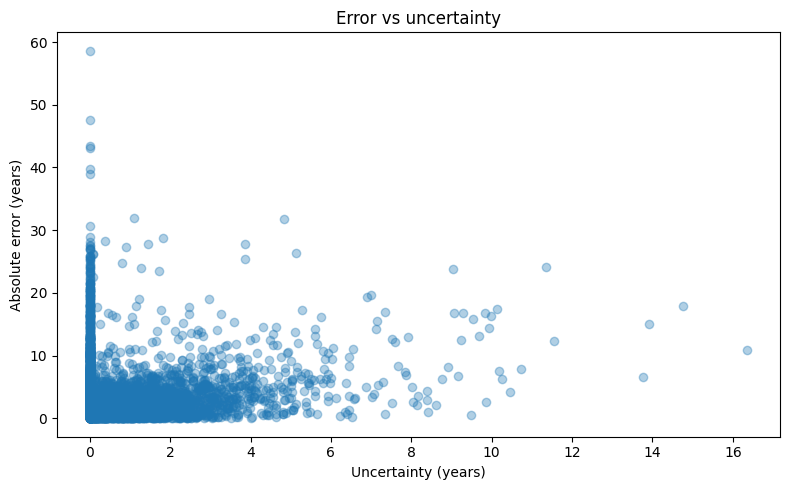

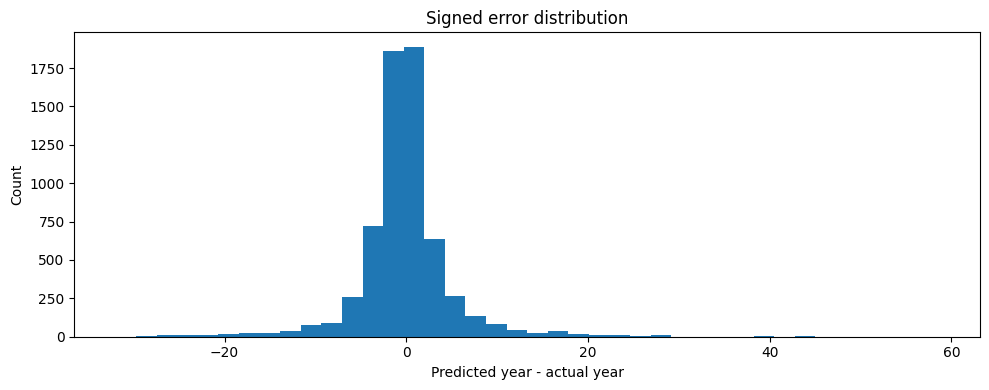


Most suspicious examples with snippets:
 actual_year   pred_year  abs_error  uncertainty_year                                                                                                                                                                                 snippet
      1933.0 1991.622803  58.622803          0.000000 Dla złodziei Dla lichwiarzy Dla kapusiów Dla zbrodniarzy Dla żandarmów i policji Dla rządzących w koalicji Dla tych piewców demokracji Dla tych co nie mają racji Dla łamagów i dla ...
      1957.0 2004.584229  47.584229          0.000000 Wszyscy weszli do ciepłych domów Zboże śpi w zacisznej stodole Padają białe śniegi na pole Padają ciepłe śniegi Padają zaciszne śniegi Aż się niebo opróżni oziębi A ziemia sie nape...
      1957.0 2000.425659  43.425659          0.000000 W kolei koleinie puszysty puszek płynie A za nim jak za łódeczką łódeczką Białe gęsie i kacze pióreczka Tak płyną płynątak biegą biegą W dół do Morza Śródziemnego A to Morze Śródzi...
      1

In [55]:
all_scores = all_scores.copy()
all_scores["signed_error"] = all_scores["pred_year"] - all_scores["actual_year"]
all_scores["abs_error"] = all_scores["signed_error"].abs()
all_scores["actual_decade"] = (all_scores["actual_year"] // 10 * 10).astype(int)

print("\nError / uncertainty correlation:")
print(all_scores[["abs_error", "uncertainty_year"]].corr().to_string())

print("\nAverage signed error:")
print(all_scores["signed_error"].mean())

print("\nBy decade:")
decade_summary = (
    all_scores.groupby("actual_decade")
    .agg(
        n=("abs_error", "size"),
        mae=("abs_error", "mean"),
        mean_uncertainty=("uncertainty_year", "mean"),
        mean_signed_error=("signed_error", "mean"),
    )
    .reset_index()
    .sort_values("actual_decade")
)
print(decade_summary.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.scatter(all_scores["uncertainty_year"], all_scores["abs_error"], alpha=0.35)
plt.xlabel("Uncertainty (years)")
plt.ylabel("Absolute error (years)")
plt.title("Error vs uncertainty")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(all_scores["signed_error"], bins=40)
plt.xlabel("Predicted year - actual year")
plt.ylabel("Count")
plt.title("Signed error distribution")
plt.tight_layout()
plt.show()

def snippet(text, n=180):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text[:n] + ("..." if len(text) > n else "")

print("\nMost suspicious examples with snippets:")
tmp = suspicious.copy()
tmp["snippet"] = tmp["lyrics"].map(snippet)
print(tmp[["actual_year", "pred_year", "abs_error", "uncertainty_year", "snippet"]].head(10).to_string(index=False))

In [ ]:
suspicious.to_csv("data/suspicious_examples.csv", index=False)
all_scores.to_csv("data/all_prediction_scores.csv", index=False)

## xAI

In [56]:
@torch.no_grad()
def predict_year_from_chunk(model, chunk_ids):
    input_ids, attention_mask = build_chunk_input(chunk_ids, tokenizer, MAX_LEN)
    input_ids = input_ids.unsqueeze(0).to(DEVICE)
    attention_mask = attention_mask.unsqueeze(0).to(DEVICE)
    pred_scaled = model(input_ids=input_ids, attention_mask=attention_mask).item()
    return float(inverse_standardize_years(pred_scaled, year_mean, year_std))

@torch.no_grad()
def explain_lyric_with_occlusion(model, text, top_k=15):
    """
    Simple local explanation:
    replace each token with [MASK] and measure how much the prediction changes.
    Positive delta_year means the token pushes the prediction toward later years.
    """
    text = preprocess(text)
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    if len(token_ids) == 0:
        token_ids = [tokenizer.unk_token_id]

    chunks = split_ids_into_chunks(token_ids, MAX_LEN - 2)
    chunk_ids = chunks[0]  # local explanation for the first chunk

    base_year = predict_year_from_chunk(model, chunk_ids)

    mask_id = tokenizer.mask_token_id if tokenizer.mask_token_id is not None else tokenizer.unk_token_id
    rows = []

    for i, tok_id in enumerate(chunk_ids):
        modified = list(chunk_ids)
        modified[i] = mask_id

        masked_year = predict_year_from_chunk(model, modified)
        tok = tokenizer.convert_ids_to_tokens([tok_id])[0]

        rows.append({
            "token": tok,
            "delta_year": base_year - masked_year,
            "masked_year": masked_year,
        })

    out = pd.DataFrame(rows).sort_values("delta_year", ascending=False)
    return base_year, out.head(top_k), out.sort_values("delta_year", ascending=True).head(top_k)

# Example on one suspicious lyric
example_text = suspicious.iloc[0]["lyrics"] if len(suspicious) else val_df.iloc[0]["lyrics"]
base_year, positive_effects, negative_effects = explain_lyric_with_occlusion(
    random_chunk_model,
    example_text,
    top_k=12
)

print("Base predicted year:", round(base_year, 2))
print("\nTokens pushing prediction later:")
print(positive_effects.to_string(index=False))

print("\nTokens pushing prediction earlier:")
print(negative_effects.to_string(index=False))

Base predicted year: 1991.62

Tokens pushing prediction later:
       token  delta_year  masked_year
        ster    2.677490  1988.945312
      ów</w>    1.853394  1989.769409
    dziś</w>    1.658081  1989.964722
     nie</w>    1.571655  1990.051147
koalicji</w>    1.541626  1990.081177
 policji</w>    1.366211  1990.256592
      co</w>    1.291016  1990.331787
         ost    1.155640  1990.467163
   gustu</w>    1.154419  1990.468384
   racji</w>    1.132324  1990.490479
     nie</w>    1.123291  1990.499512
          wy    1.120850  1990.501953

Tokens pushing prediction earlier:
      token  delta_year  masked_year
        kle   -4.477905  1996.100708
    Dla</w>   -2.127686  1993.750488
  wasze</w>   -1.711060  1993.333862
Właśnie</w>   -1.601562  1993.224365
     żandar   -1.519165  1993.141968
    mów</w>   -1.305298  1992.928101
    Dla</w>   -1.179321  1992.802124
    was</w>   -0.958496  1992.581299
     ru</w>   -0.943115  1992.565918
        Pod   -0.829102  1992.451904


In [57]:
@torch.no_grad()
def aggregate_token_year_effects(model, df_eval, n_examples=150, max_tokens_per_text=64, min_count=5):
    """
    Builds a global token -> average delta_year table.
    Useful for finding tokens associated with earlier / later eras.
    """
    sample_df = df_eval.sample(min(n_examples, len(df_eval)), random_state=SEED).reset_index(drop=True)

    token_effects = {}

    mask_id = tokenizer.mask_token_id if tokenizer.mask_token_id is not None else tokenizer.unk_token_id

    for _, row in sample_df.iterrows():
        text = preprocess(row["lyrics"])
        token_ids = tokenizer.encode(text, add_special_tokens=False)
        if len(token_ids) == 0:
            continue

        token_ids = token_ids[:max_tokens_per_text]
        chunk_ids = split_ids_into_chunks(token_ids, MAX_LEN - 2)[0]

        base_year = predict_year_from_chunk(model, chunk_ids)

        for i, tok_id in enumerate(chunk_ids):
            tok = tokenizer.convert_ids_to_tokens([tok_id])[0]
            clean_tok = tok.replace("##", "").strip()

            if len(clean_tok) <= 1:
                continue

            modified = list(chunk_ids)
            modified[i] = mask_id
            masked_year = predict_year_from_chunk(model, modified)

            delta_year = base_year - masked_year
            token_effects.setdefault(clean_tok, []).append(delta_year)

    rows = []
    for tok, deltas in token_effects.items():
        if len(deltas) >= min_count:
            rows.append({
                "token": tok,
                "count": len(deltas),
                "mean_delta_year": float(np.mean(deltas)),
                "std_delta_year": float(np.std(deltas)),
            })

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    out = out.sort_values("mean_delta_year").reset_index(drop=True)
    return out

xai_table = aggregate_token_year_effects(
    random_chunk_model,
    val_df,
    n_examples=150,
    max_tokens_per_text=64,
    min_count=5
)

print("\nMost early-associated tokens:")
print(xai_table.head(20).to_string(index=False))

print("\nMost late-associated tokens:")
print(xai_table.tail(20).to_string(index=False))


Most early-associated tokens:
     token  count  mean_delta_year  std_delta_year
   Czy</w>     13        -2.585956        3.798403
    Że</w>      6        -2.470093        4.504318
  razy</w>      5        -2.195581        2.490209
     n</w>      5        -2.153540        4.876798
      koch     10        -2.040002        1.528379
        Po      6        -1.728678        2.380179
  dzie</w>      5        -1.596753        2.903112
 Nigdy</w>      5        -1.521533        1.824465
    ją</w>     11        -1.508179        2.281368
    Po</w>     12        -1.500427        3.265796
        mi      7        -1.470668        3.576959
   Tak</w>      9        -1.455648        0.994430
        Wy      8        -1.453339        1.701529
    li</w>      5        -1.442529        2.842300
Ludzie</w>      7        -1.323312        3.254237
   ani</w>     16        -1.265877        1.208114
  pięć</w>      7        -1.216989        1.022115
   czę</w>      7        -1.184675        2.229504


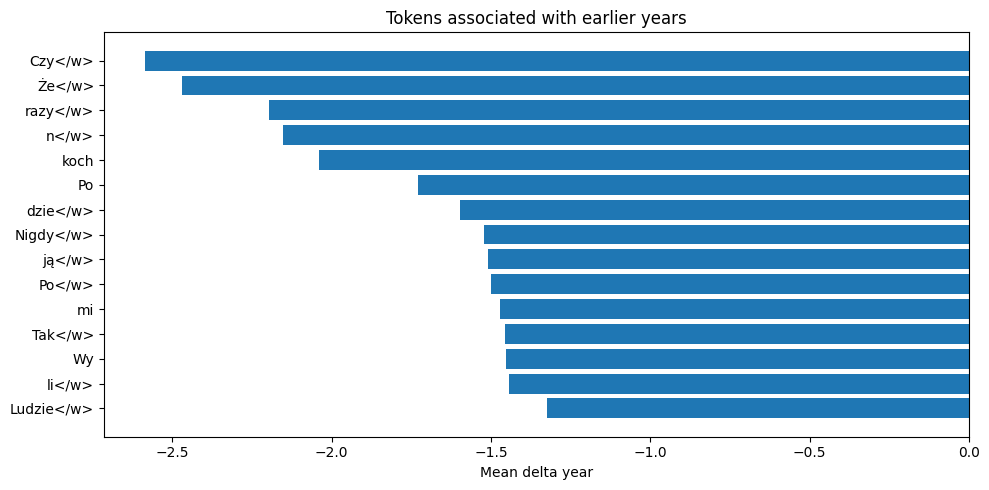

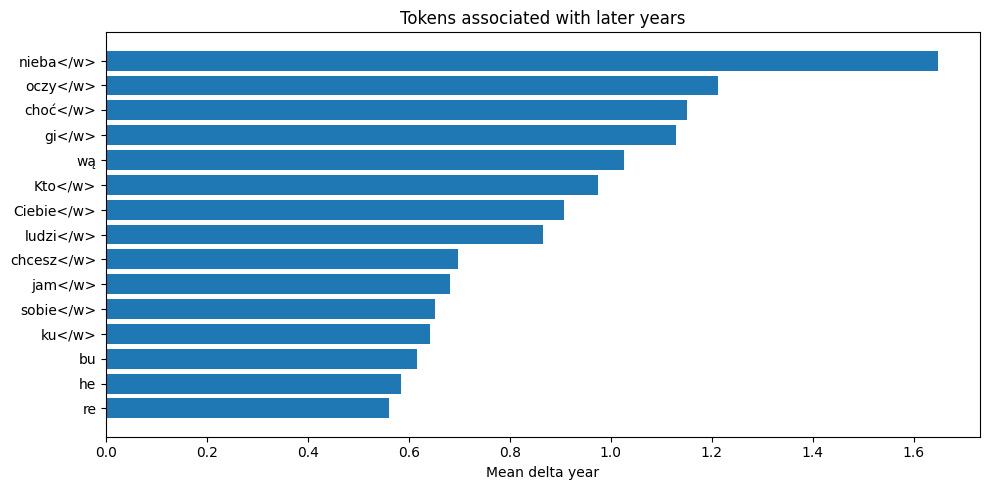

In [58]:
if len(xai_table) > 0:
    top_early = xai_table.head(15).copy()
    top_late = xai_table.tail(15).copy()

    plt.figure(figsize=(10, 5))
    plt.barh(top_early["token"][::-1], top_early["mean_delta_year"][::-1])
    plt.xlabel("Mean delta year")
    plt.title("Tokens associated with earlier years")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.barh(top_late["token"], top_late["mean_delta_year"])
    plt.xlabel("Mean delta year")
    plt.title("Tokens associated with later years")
    plt.tight_layout()
    plt.show()

## TESTING ON OWN EXAMPLES

In [44]:
sample_text = "Lala la la la, życie jest piękne, tak tak, lalala"
pred_info = predict_scaled_random_chunk(random_chunk_model, sample_text, n_samples=32)
print("Predicted year (mean):", round(pred_info["mean_year"], 2))
print("Predicted year (std):", round(pred_info["std_year"], 2))

Predicted year (mean): 2005.95
Predicted year (std): 0.0


In [45]:
sample_text = "Lala la la la, życie jest piękne, tak tak, lalala"
pred_year = predict_scaled_first_last(first_last_model, sample_text, max_len=MAX_LEN)
print(f"Predicted year for sample lyric: {pred_year:.2f}")

Predicted year for sample lyric: 1994.47


In [ ]:
wrong_data = pd.read_csv("data/piosenki_zle.csv")
wrong_data

,Unnamed: 0,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,229762,Ikar,rap,Kieras,1,17,{},"Stary przyjacielu, śmiało mogę Cię tak nazwać\...",278706,pl,pl,pl
1,238232,Skończ smucić kolego,rap,1Smack,1,23,{},"Skoncz smucic kolego\n\nWrzuć to na fejsa, lub...",307508,pl,pl,pl
2,262350,Gra w ciemno,rap,Hudini (Poland),10,102,{},[1st verse: Hudini]\nKiedy gasną światła zmywa...,359094,pl,pl,pl
3,445977,Głupia Dupa,rap,Muzzy (PL),1,206,{},"Joł, to była dziwna chwila i stary wciąż to ws...",737353,pl,pl,pl
4,229762,Ikar,rap,Kieras,1,17,{},"Stary przyjacielu, śmiało mogę Cię tak nazwać\...",278706,pl,pl,pl
5,238232,Skończ smucić kolego,rap,1Smack,1,23,{},"Skoncz smucic kolego\n\nWrzuć to na fejsa, lub...",307508,pl,pl,pl
6,262350,Gra w ciemno,rap,Hudini (Poland),10,102,{},[1st verse: Hudini]\nKiedy gasną światła zmywa...,359094,pl,pl,pl
7,445977,Głupia Dupa,rap,Muzzy (PL),1,206,{},"Joł, to była dziwna chwila i stary wciąż to ws...",737353,pl,pl,pl
8,625316,Ciuralla,rock,Cjalis,1,1336,{},"Ciuralla, Ciuralla, Ciuralla, Ciuralala\nCiura...",2102423,pl,pl,pl
9,730321,Stratosfera,rap,Te-Tris,1,2654,{},"[Refren]\nI chyba bywam wśród tych, którzy sta...",2339515,pl,pl,pl


In [56]:
fixed_data = pd.DataFrame(columns=["title", "tag", "artist", "predicted_year"])
for idx, row in wrong_data.iterrows():
    text = row["lyrics"]
    pred_year = predict_scaled_first_last(first_last_model, text, max_len=MAX_LEN)
    fixed_data.loc[-1] = [row["title"], row["tag"], row["artist"], pred_year]
    fixed_data.index = fixed_data.index + 1
fixed_data
    

,title,tag,artist,predicted_year
27,Ikar,rap,Kieras,2013.785400
26,Skończ smucić kolego,rap,1Smack,2015.760376
25,Gra w ciemno,rap,Hudini (Poland),2015.748657
24,Głupia Dupa,rap,Muzzy (PL),2013.550293
23,Ikar,rap,Kieras,2013.785400
22,Skończ smucić kolego,rap,1Smack,2015.760376
21,Gra w ciemno,rap,Hudini (Poland),2015.748657
20,Głupia Dupa,rap,Muzzy (PL),2013.550293
19,Ciuralla,rock,Cjalis,2016.032471
18,Stratosfera,rap,Te-Tris,2014.024902
